# This notebook was ran on kaggel GPU T4

In [22]:
# !pip install torch_geometric -q
# !pip install monty -q
# !pip install pymatgen -q

In [3]:
import torch
import torch_geometric
print("torch:", torch.__version__)
print("torch_geometric:", torch_geometric.__version__)
print("CUDA available:", torch.cuda.is_available())   # should be True with GPU on

torch: 2.10.0+cu128
torch_geometric: 2.7.0
CUDA available: True


In [4]:
import pandas as pd
from monty.serialization import loadfn

base = "/kaggle/input/datasets/ameeyabhusansahoo/materials-ml-cathode-data"   
df = pd.read_parquet(f"{base}/li_electrodes_clean.parquet")
structures = loadfn(f"{base}/host_structures.json")
print(f"{len(df)} rows, {len(structures)} structures")

2634 rows, 2634 structures


In [5]:
# import os
# for root, dirs, files in os.walk("/kaggle/input"):
#     for f in files:
#         print(os.path.join(root, f))

In [6]:
import numpy as np
import torch
from torch_geometric.data import Data

def capped_neighbors(structure, r=6.0, max_neighbors=12):
    """Each atom's nearest `max_neighbors` within radius `r`, periodic images included."""
    centers, neighbors, offsets, distances = structure.get_neighbor_list(r)
    src, dst, edist = [], [], []
    for i in range(len(structure)):
        mask = centers == i
        nbr = neighbors[mask]
        d = distances[mask]
        order = np.argsort(d)[:max_neighbors]
        src.extend([i] * len(order))
        dst.extend(nbr[order])
        edist.extend(d[order])
    return np.array(src), np.array(dst), np.array(edist)

def structure_to_graph(structure, target, r=6.0, max_neighbors=12):
    src, dst, dist = capped_neighbors(structure, r, max_neighbors)
    z = torch.tensor([site.specie.Z for site in structure], dtype=torch.long)
    edge_index = torch.tensor([src, dst], dtype=torch.long)
    edge_attr = torch.tensor(dist, dtype=torch.float).unsqueeze(1)
    y = torch.tensor([target], dtype=torch.float)
    return Data(x=z, edge_index=edge_index, edge_attr=edge_attr, y=y)

# Sanity check on one example before processing all 2,634
example_id = df["battery_id"].iloc[100]   # pick something non-trivial
example = structures[example_id]
target_v = df.loc[df["battery_id"] == example_id, "average_voltage"].values[0]
g = structure_to_graph(example, target_v)
print(g)
print("atomic numbers:", g.x.tolist())
print("target voltage:", g.y.item())

Data(x=[6], edge_index=[2, 72], edge_attr=[72, 1], y=[1])
atomic numbers: [42, 42, 8, 8, 8, 8]
target voltage: 1.6804031133651733


/tmp/ipykernel_58/3578918194.py:22: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /pytorch/torch/csrc/utils/tensor_new.cpp:253.)
  edge_index = torch.tensor([src, dst], dtype=torch.long)


In [7]:
from tqdm.auto import tqdm

graphs = []
skipped = []
for _, row in tqdm(df.iterrows(), total=len(df)):
    bid = row["battery_id"]
    s = structures.get(bid)
    if s is None:
        skipped.append(bid)
        continue
    try:
        g = structure_to_graph(s, row["average_voltage"])
        g.battery_id = bid          # attach id for traceability and grouped CV
        g.chemsys = row["chemsys"]   # needed for honest grouped split later
        graphs.append(g)
    except Exception as e:
        skipped.append((bid, str(e)))

print(f"Built {len(graphs)} graphs, skipped {len(skipped)}")

  0%|          | 0/2634 [00:00<?, ?it/s]

Built 2634 graphs, skipped 0


In [8]:
torch.save(graphs, "/kaggle/working/graphs.pt")
print(f"Saved {len(graphs)} graphs")

# In future sessions, we reload with:
# graphs = torch.load("/kaggle/working/graphs.pt", weights_only=False)

Saved 2634 graphs


In [9]:
import numpy as np
from collections import defaultdict

chemsys_to_idx = defaultdict(list)
for i, g in enumerate(graphs):
    chemsys_to_idx[g.chemsys].append(i)

unique_chemsys = np.array(list(chemsys_to_idx.keys()))
rng = np.random.default_rng(42)
shuffled = rng.permutation(unique_chemsys)

n = len(shuffled)
train_cs = set(shuffled[: int(0.8 * n)])
val_cs   = set(shuffled[int(0.8 * n) : int(0.9 * n)])
test_cs  = set(shuffled[int(0.9 * n) :])

train_graphs = [g for g in graphs if g.chemsys in train_cs]
val_graphs   = [g for g in graphs if g.chemsys in val_cs]
test_graphs  = [g for g in graphs if g.chemsys in test_cs]

print(f"chemistries: train {len(train_cs)}  val {len(val_cs)}  test {len(test_cs)}")
print(f"graphs:      train {len(train_graphs)}  val {len(val_graphs)}  test {len(test_graphs)}")

chemistries: train 497  val 62  test 63
graphs:      train 2026  val 167  test 441


In [10]:
from torch_geometric.loader import DataLoader

train_loader = DataLoader(train_graphs, batch_size=64, shuffle=True)
val_loader   = DataLoader(val_graphs,   batch_size=64)
test_loader  = DataLoader(test_graphs,  batch_size=64)

# Inspect one batch to understand PyG's batching
batch = next(iter(train_loader))
print(batch)
print(f"graphs in batch: {batch.num_graphs}")
print(f"total nodes:     {batch.x.shape[0]}")
print(f"total edges:     {batch.edge_index.shape[1]}")
print(f"batch tensor:    {batch.batch[:30].tolist()}...")

DataBatch(x=[1869], edge_index=[2, 22428], edge_attr=[22428, 1], y=[64], battery_id=[64], chemsys=[64], batch=[1869], ptr=[65])
graphs in batch: 64
total nodes:     1869
total edges:     22428
batch tensor:    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1]...


In [11]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import CGConv, global_mean_pool


class GaussianRBF(nn.Module):
    """Expand each distance into a Gaussian basis vector."""
    def __init__(self, num_basis=50, cutoff=6.0):
        super().__init__()
        self.register_buffer("centers", torch.linspace(0, cutoff, num_basis))
        self.gamma = 1.0 / (cutoff / num_basis) ** 2

    def forward(self, d):
        # d: [n_edges, 1]  ->  [n_edges, num_basis]
        return torch.exp(-self.gamma * (d - self.centers.unsqueeze(0)) ** 2)


class CGCNN(nn.Module):
    def __init__(self, hidden_dim=64, num_conv=3, num_rbf=50,
                 cutoff=6.0, num_elements=100):
        super().__init__()
        self.atom_embedding = nn.Embedding(num_elements, hidden_dim)
        self.rbf = GaussianRBF(num_basis=num_rbf, cutoff=cutoff)
        self.convs = nn.ModuleList([
            CGConv(hidden_dim, dim=num_rbf, batch_norm=True)
            for _ in range(num_conv)
        ])
        self.head = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, 1),
        )

    def forward(self, data):
        x = self.atom_embedding(data.x)              # [n_nodes, hidden_dim]
        e = self.rbf(data.edge_attr)                 # [n_edges, num_rbf]
        for conv in self.convs:
            x = conv(x, data.edge_index, e)          # message passing
        g = global_mean_pool(x, data.batch)          # [batch_size, hidden_dim]
        return self.head(g).squeeze(-1)              # [batch_size]

In [12]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = CGCNN().to(device)

batch = next(iter(train_loader)).to(device)
pred = model(batch)

print(f"device: {device}")
print(f"pred shape: {pred.shape}")   # expect [64]
print(f"target shape: {batch.y.shape}")  # expect [64]
print(f"pred (untrained) first 5: {pred[:5].detach().cpu().tolist()}")
print(f"target first 5:           {batch.y[:5].cpu().tolist()}")

n_params = sum(p.numel() for p in model.parameters())
print(f"\nmodel parameters: {n_params:,}")

device: cuda
pred shape: torch.Size([64])
target shape: torch.Size([64])
pred (untrained) first 5: [-0.2563267946243286, -0.3347780704498291, -0.32220789790153503, -0.25494086742401123, -0.4801935851573944]
target first 5:           [2.9542412757873535, 1.9737157821655273, 4.110077857971191, 2.3361024856567383, 4.2334136962890625]

model parameters: 79,745


In [13]:
from torch.optim import Adam
from torch.optim.lr_scheduler import ReduceLROnPlateau
import copy

def train_epoch(model, loader, optimizer, device):
    model.train()
    total_loss, n = 0.0, 0
    for batch in loader:
        batch = batch.to(device)
        optimizer.zero_grad()
        pred = model(batch)
        loss = F.mse_loss(pred, batch.y)   # MSE for smooth gradients
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * batch.num_graphs
        n += batch.num_graphs
    return total_loss / n

@torch.no_grad()
def evaluate(model, loader, device):
    model.eval()
    abs_err, n = 0.0, 0
    for batch in loader:
        batch = batch.to(device)
        pred = model(batch)
        abs_err += (pred - batch.y).abs().sum().item()
        n += batch.num_graphs
    return abs_err / n   # MAE — the interpretable metric

In [14]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = CGCNN().to(device)
optimizer = Adam(model.parameters(), lr=1e-3)
scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=10)

best_val = float('inf')
best_state = None
patience, bad_epochs = 25, 0
history = {'train_mse': [], 'val_mae': []}

for epoch in range(1, 201):
    train_mse = train_epoch(model, train_loader, optimizer, device)
    val_mae = evaluate(model, val_loader, device)
    scheduler.step(val_mae)
    history['train_mse'].append(train_mse)
    history['val_mae'].append(val_mae)

    if val_mae < best_val:
        best_val = val_mae
        best_state = copy.deepcopy(model.state_dict())
        bad_epochs = 0
    else:
        bad_epochs += 1

    if epoch == 1 or epoch % 5 == 0:
        lr = optimizer.param_groups[0]['lr']
        print(f"epoch {epoch:3d}  train MSE {train_mse:.4f}  "
              f"val MAE {val_mae:.3f} V  best {best_val:.3f}  lr {lr:.2e}")

    if bad_epochs >= patience:
        print(f"\nEarly stopping at epoch {epoch}.  Best val MAE: {best_val:.3f} V")
        break

model.load_state_dict(best_state)
print(f"\nBest val MAE: {best_val:.3f} V")

epoch   1  train MSE 3.5732  val MAE 0.683 V  best 0.683  lr 1.00e-03
epoch   5  train MSE 0.5783  val MAE 0.828 V  best 0.622  lr 1.00e-03
epoch  10  train MSE 0.4862  val MAE 0.573 V  best 0.547  lr 1.00e-03
epoch  15  train MSE 0.4328  val MAE 0.572 V  best 0.533  lr 1.00e-03
epoch  20  train MSE 0.3893  val MAE 0.616 V  best 0.533  lr 1.00e-03
epoch  25  train MSE 0.3469  val MAE 0.539 V  best 0.533  lr 5.00e-04
epoch  30  train MSE 0.3062  val MAE 0.624 V  best 0.533  lr 5.00e-04
epoch  35  train MSE 0.2938  val MAE 0.580 V  best 0.533  lr 2.50e-04

Early stopping at epoch 38.  Best val MAE: 0.533 V

Best val MAE: 0.533 V


In [15]:
test_mae = evaluate(model, test_loader, device)
print(f"--- Honest scorecard ---")
print(f"Dummy baseline:                 0.88 V")
print(f"LightGBM composition (grouped): 0.58 V")
print(f"CGCNN structure (held-out test):{test_mae:.3f} V")

--- Honest scorecard ---
Dummy baseline:                 0.88 V
LightGBM composition (grouped): 0.58 V
CGCNN structure (held-out test):0.469 V


In [16]:
from sklearn.metrics import r2_score

@torch.no_grad()
def predictions(model, loader, device):
    model.eval()
    ys, ps = [], []
    for batch in loader:
        batch = batch.to(device)
        ps.append(model(batch).cpu())
        ys.append(batch.y.cpu())
    return torch.cat(ys).numpy(), torch.cat(ps).numpy()

y_test, y_pred = predictions(model, test_loader, device)
print(f"Test MAE: {(abs(y_test - y_pred)).mean():.3f} V")
print(f"Test R²:  {r2_score(y_test, y_pred):.3f}")

Test MAE: 0.469 V
Test R²:  0.557


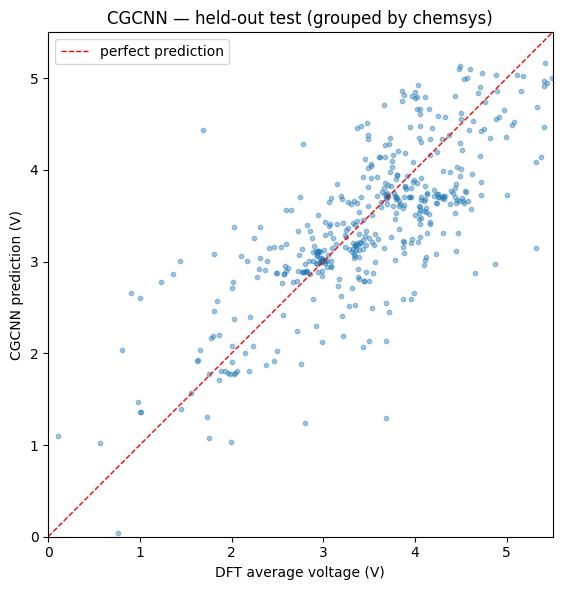

In [17]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(y_test, y_pred, s=10, alpha=0.4)
ax.plot([0, 5.5], [0, 5.5], "r--", linewidth=1, label="perfect prediction")
ax.set_xlabel("DFT average voltage (V)")
ax.set_ylabel("CGCNN prediction (V)")
ax.set_title("CGCNN — held-out test (grouped by chemsys)")
ax.set_xlim(0, 5.5); ax.set_ylim(0, 5.5); ax.set_aspect("equal")
ax.legend()
fig.tight_layout()
fig.savefig("/kaggle/working/cgcnn_predicted_vs_actual.png", dpi=150, bbox_inches="tight")
plt.show()

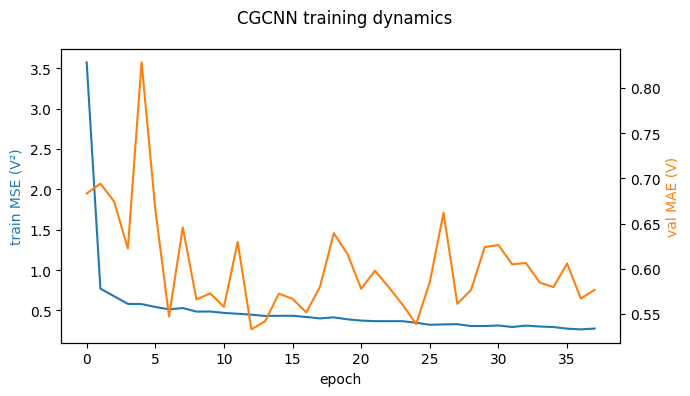

In [18]:
fig, ax1 = plt.subplots(figsize=(7, 4))
ax1.plot(history['train_mse'], label="train MSE", color="tab:blue")
ax1.set_xlabel("epoch")
ax1.set_ylabel("train MSE (V²)", color="tab:blue")
ax2 = ax1.twinx()
ax2.plot(history['val_mae'], label="val MAE", color="tab:orange")
ax2.set_ylabel("val MAE (V)", color="tab:orange")
fig.suptitle("CGCNN training dynamics")
fig.tight_layout()
fig.savefig("/kaggle/working/cgcnn_learning_curves.png", dpi=150, bbox_inches="tight")
plt.show()

In [19]:
import numpy as np

def run_one_seed(seed, max_epochs=200, patience=25):
    torch.manual_seed(seed)
    np.random.seed(seed)
    model = CGCNN().to(device)
    optimizer = Adam(model.parameters(), lr=1e-3)
    scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=10)
    best_val, best_state, bad = float('inf'), None, 0

    for epoch in range(1, max_epochs + 1):
        train_epoch(model, train_loader, optimizer, device)
        val_mae = evaluate(model, val_loader, device)
        scheduler.step(val_mae)
        if val_mae < best_val:
            best_val, best_state, bad = val_mae, copy.deepcopy(model.state_dict()), 0
        else:
            bad += 1
        if bad >= patience:
            break

    model.load_state_dict(best_state)
    y_t, y_p = predictions(model, test_loader, device)
    return (abs(y_t - y_p).mean(), r2_score(y_t, y_p), best_val)

seeds = [0, 1, 2, 42, 7]   # 5 seeds; drop to 3 if time is tight
results = []
for s in seeds:
    mae, r2, val = run_one_seed(s)
    results.append((s, mae, r2, val))
    print(f"seed {s:3d}:  best val {val:.3f}   test MAE {mae:.3f}   test R² {r2:.3f}")

maes = np.array([r[1] for r in results])
r2s  = np.array([r[2] for r in results])
print(f"\nTest MAE: {maes.mean():.3f} ± {maes.std():.3f} V")
print(f"Test R²:  {r2s.mean():.3f} ± {r2s.std():.3f}")

seed   0:  best val 0.545   test MAE 0.499   test R² 0.527
seed   1:  best val 0.573   test MAE 0.507   test R² 0.495
seed   2:  best val 0.601   test MAE 0.519   test R² 0.481
seed  42:  best val 0.575   test MAE 0.483   test R² 0.494
seed   7:  best val 0.583   test MAE 0.505   test R² 0.508

Test MAE: 0.503 ± 0.012 V
Test R²:  0.501 ± 0.015


In [21]:
#!pip install matminer -q

from matminer.featurizers.composition import ElementProperty
from matminer.featurizers.conversions import StrToComposition
from lightgbm import LGBMRegressor

# Featurize the same dataframe (same rows, same chemsys, same target)
df_feat = StrToComposition().featurize_dataframe(df.copy(), "framework_formula")
df_feat = ElementProperty.from_preset("magpie").featurize_dataframe(df_feat, "composition")

# Use the SAME train/test chemsys sets the GNN used
train_mask = df_feat["chemsys"].isin(train_cs)
test_mask  = df_feat["chemsys"].isin(test_cs)

feature_cols = [c for c in df_feat.columns if c.startswith("MagpieData")]
X_train = df_feat.loc[train_mask, feature_cols].values
y_train = df_feat.loc[train_mask, "average_voltage"].values
X_test  = df_feat.loc[test_mask,  feature_cols].values
y_test  = df_feat.loc[test_mask,  "average_voltage"].values

lgb = LGBMRegressor(n_estimators=500, learning_rate=0.05, random_state=42, verbose=-1)
lgb.fit(X_train, y_train)
pred = lgb.predict(X_test)

base_mae = np.abs(pred - y_test).mean()
base_r2 = r2_score(y_test, pred)
print(f"LightGBM baseline on SAME grouped test split:")
print(f"  MAE: {base_mae:.3f} V")
print(f"  R²:  {base_r2:.3f}")

StrToComposition:   0%|          | 0/2634 [00:00<?, ?it/s]

ElementProperty:   0%|          | 0/2634 [00:00<?, ?it/s]

LightGBM baseline on SAME grouped test split:
  MAE: 0.518 V
  R²:  0.477


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


In [25]:
torch.save(model.state_dict(), f"/kaggle/working/cgcnn_seed{seeds}.pt")